In [1]:
from dask.distributed import Client
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import numpy as np
import xarray as xr
import cmocean as cm
import cartopy.crs as ccrs
import cmocean as cm
import cartopy.feature as cft
import cftime
import IPython.display
import sys, os, warnings
import matplotlib.animation as animation
from cartopy.mpl.geoaxes import GeoAxes  # Import GeoAxes for Cartopy plotting
from mpl_toolkits.axes_grid1 import AxesGrid
import gsw
from xgcm import Grid
import intake
import cf_xarray as cfxr
from access_nri_intake.experiment import use_datastore
from access_nri_intake.source import builders
import os
from xarray import SerializationWarning
import matplotlib.patches as mpatches

In [2]:
client = Client(n_workers=28)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37675,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46869,Total threads: 1
Dashboard: /proxy/40275/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:34931,


In [3]:
expt_datastore = intake.open_esm_datastore(
    "./ssp585_th.json", 
    columns_with_iterables=[
            "variable",
            "variable_long_name",
            "variable_standard_name",
            "variable_cell_methods",
            "variable_units",
    ] # This is important
)


In [4]:
catalog = intake.cat.access_nri

In [5]:
# time period
start_time1='2152-06-01'
end_time1='2152-08-31'

start_time2='2153-06-01'
end_time2='2153-08-31'

start_time3='2154-06-01'
end_time3='2154-08-31'

In [6]:
# time period
start_time='2152-01-01'
end_time='2154-12-31'

In [7]:
new_coord = xr.open_dataarray('/scratch/x77/hm1221/nc_files/lat_to_shelf_bin.nc')

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/argopy/__init__.py:32: DeprecationWarning: The 'argopy.utilities' has moved to 'argopy.utils'. After 0.1.15, importing 'utilities' will raise an error. Please update your script.
  from . import utilities  # noqa: E402  # being deprecated until 0.1.15, then remove
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/wavespectra/core/npstats.py:238: DeprecationWarning: invalid escape sequence '\s'
  """Gaussian frequency spectrum (Bunney et al., 2014).
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/wavespectra/output/ww3.py:25: ResourceWarning: unclosed file <_io.TextIOWrapper name='/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/wavespectra/output/ww3.yml' mode='r' encoding='UTF-8'>
  VAR_ATTRIBUTES = yaml.load(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/w

In [8]:
rho_th_mean_new = xr.open_dataarray('/g/data/x77/hm1221/PhD_P1_data/rho_mean_time_th.nc')
rho_ctrl_mean_new = xr.open_dataarray('/g/data/x77/hm1221/PhD_P1_data/rho_mean_time_ctrl.nc')

In [9]:
bound_up_mean = xr.open_dataarray('/scratch/x77/hm1221/nc_files/bound_up_mean.nc')
bound_low_mean= xr.open_dataarray("/scratch/x77/hm1221/nc_files/bound_low_mean.nc")

In [11]:
buoyancy_th = expt_datastore.search(variable="buoyfreq2_wt",frequency = '1mon').to_dask()
buoyancy_th = buoyancy_th.buoyfreq2_wt.sel(time = slice(start_time, end_time))

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:475: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  cat = self.__class__({'esmcat': self.esmcat.dict(), 'df': esmcat_results})
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [12]:
buoyancy_ctrl = catalog['01deg_jra55v13_ryf9091'].search(variable="buoyfreq2_wt",frequency = '1mon').to_dask()
buoyancy_ctrl = buoyancy_ctrl.buoyfreq2_wt.sel(time = slice(start_time, end_time))

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:475: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  cat = self.__class__({'esmcat': self.esmcat.dict(), 'df': esmcat_results})
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [13]:
def var_winter(var):
    var_1 = var.sel(yt_ocean = slice(-90,-50)).sel(time = slice(start_time1,end_time1)).mean('time').load()
    var_2 = var.sel(yt_ocean = slice(-90,-50)).sel(time = slice(start_time2,end_time2)).mean('time').load()
    var_3 = var.sel(yt_ocean = slice(-90,-50)).sel(time = slice(start_time3,end_time3)).mean('time').load()

    var_winter = (var_1+var_2+var_3)/3.

    return var_winter

In [14]:
buoyancy_ctrl_winter = var_winter(buoyancy_ctrl)
buoyancy_th_winter = var_winter(buoyancy_th)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 72.14 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 72.14 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/cli

In [15]:
st_ocean = new_coord.st_ocean.values

In [16]:
# Interpolate along yu_ocean onto the new yt_ocean coordinate
buoyancy_ctrl_winter = buoyancy_ctrl_winter.interp(sw_ocean=st_ocean)

# Rename the coordinate dimension from 'yu_ocean' to 'yt_ocean'
buoyancy_ctrl_winter = buoyancy_ctrl_winter.rename({'sw_ocean': 'st_ocean'})

In [17]:
# Interpolate along yu_ocean onto the new yt_ocean coordinate
buoyancy_th_winter = buoyancy_th_winter.interp(sw_ocean=st_ocean)

# Rename the coordinate dimension from 'yu_ocean' to 'yt_ocean'
buoyancy_th_winter = buoyancy_th_winter.rename({'sw_ocean': 'st_ocean'})

In [18]:
# transfer the data to latitude to shelf
def Trans_lat_to_shelf(var,new_coord):
    target_bin = np.arange(-20.,60,0.1)
    ds = xr.Dataset({'var': var, 'new_coord': new_coord})
    grid = Grid(ds, coords={'Y': {'center':'yt_ocean'}}, periodic=False)
    # transfer vars 
    var_new = grid.transform(ds['var'], 'Y', target_bin, target_data=ds['new_coord'],method='linear')
    var_new = var_new.rename({'new_coord': 'yt_ocean'})
    var_new_1 = var_new.sel(xt_ocean = slice(-40,80))
    var_new_2 = var_new.sel(xt_ocean = slice(-280,-60))
    var_new = xr.concat([var_new_2,var_new_1],dim = 'xt_ocean')
    var_mean  = var_new.mean('xt_ocean').load()

    return [var_new,var_mean]

In [19]:
buoyancy_ctrl_new,buoyancy_ctrl_mean_new = Trans_lat_to_shelf(buoyancy_ctrl_winter,new_coord)
buoyancy_th_new,buoyancy_th_mean_new = Trans_lat_to_shelf(buoyancy_th_winter,new_coord)


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/xgcm/grid.py:1283: DeprecationWarning: The `xgcm.Axis` class will be deprecated in the future. Please make sure to use the `xgcm.Grid` methods for your work instead.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computation methods will be removed, in favour of using the Grid computation methods instead. i.e. use `Grid.transform` instead of `Axis.transform`
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/xgcm/grid.py:1283: DeprecationWarning: The `xgcm.Axis` class will be deprecated in the future. Please make sure to use the `xgcm.Grid` methods for your work instead.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computa

In [20]:
manual_positions = [
    (5, 100), 
    (5, 300),
    (6,1000)
]
levs_dens = [32.0,32.3,32.5]

In [21]:
# land mask
land = xr.where(np.isnan(buoyancy_ctrl_mean_new[:,:].rename('land')), 1, np.nan)

In [22]:
background_1 = xr.DataArray(
    data=np.ones_like(buoyancy_ctrl_mean_new),
    coords=buoyancy_ctrl_mean_new.coords,
    dims=buoyancy_ctrl_mean_new.dims,
    name='ones_array'
)

In [24]:
mid_bound = xr.open_dataarray('/g/data/x77/hm1221/PhD_P1_data/bound_mid_mean.nc')

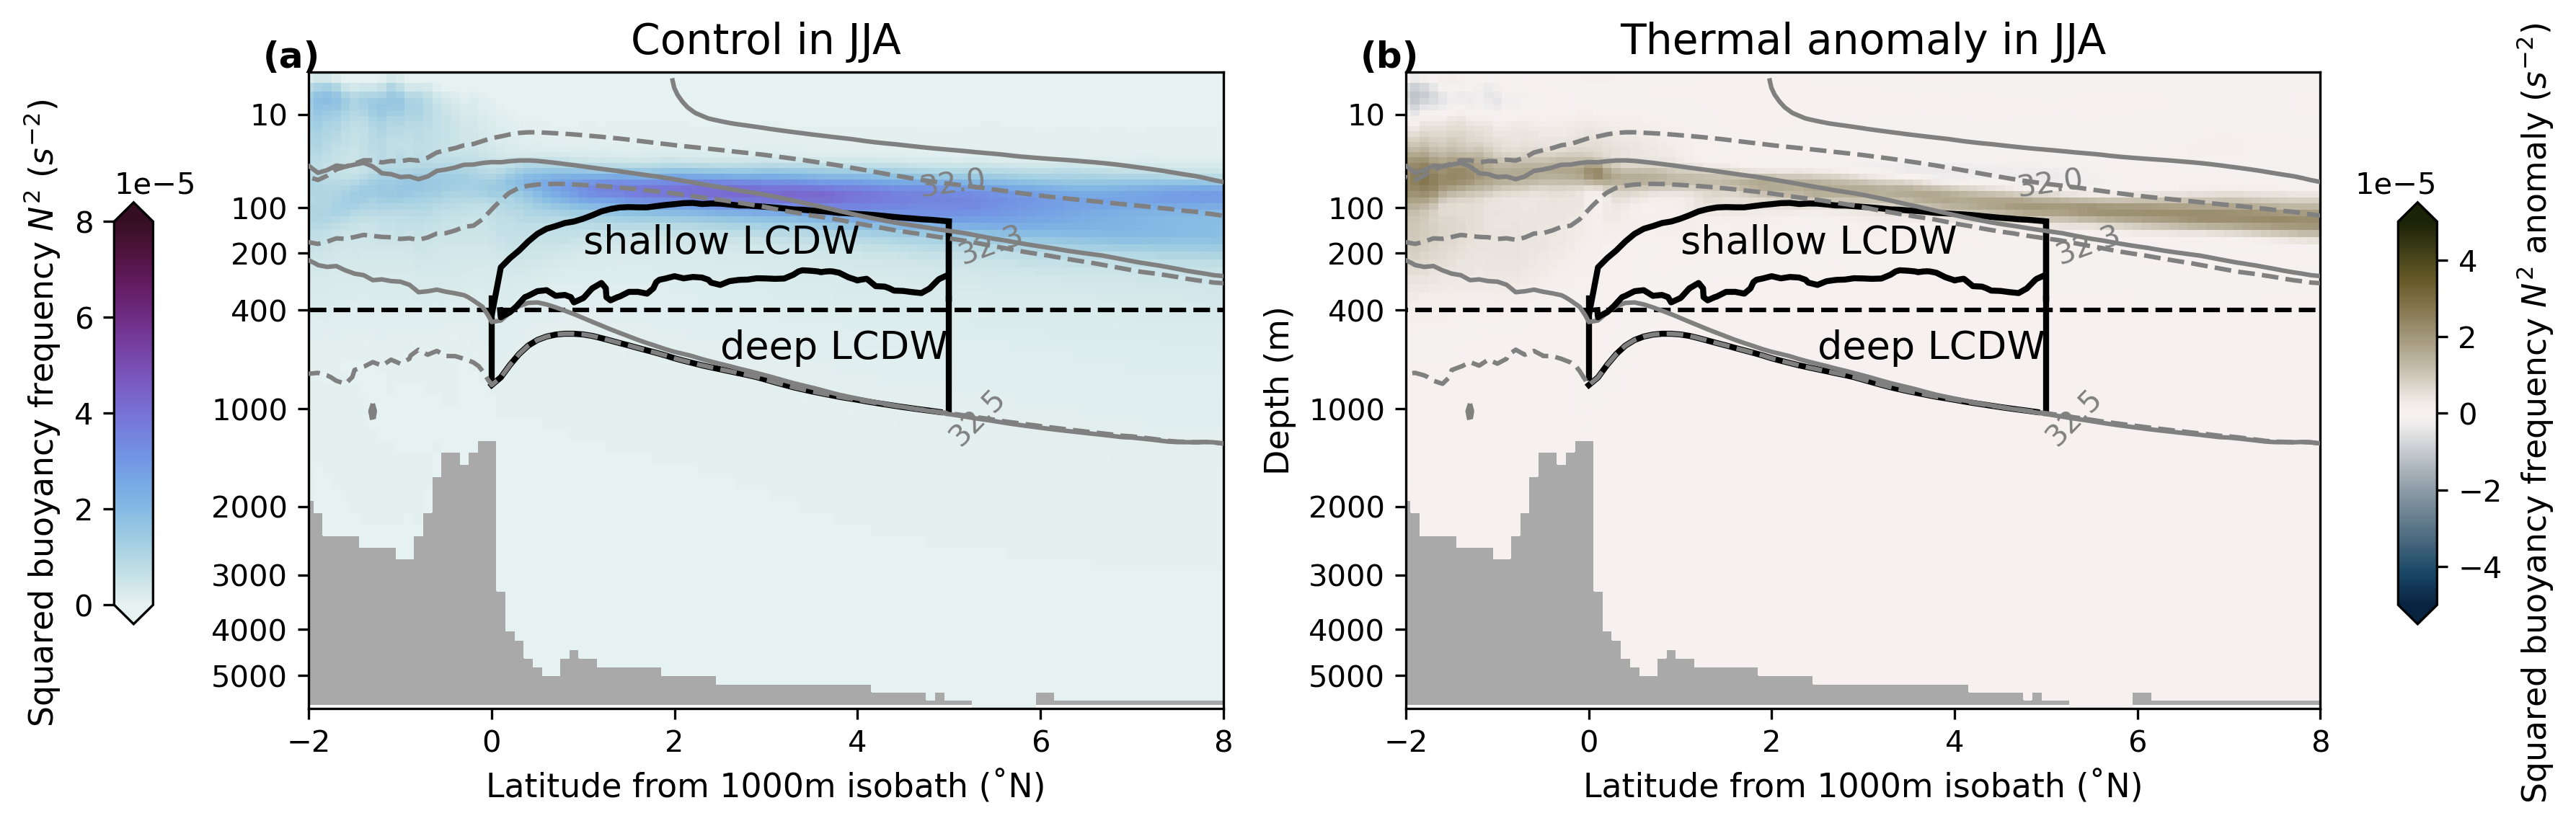

In [26]:
# For Figure 6
fig = plt.figure(figsize=(12,13),dpi = 300)
#ax = plt.subplot(2,1,1)
#plt.plot(rho_bins[1:],(shf_hist_ctrl/1e15).values,color = 'k')
#plt.plot(rho_bins[1:],(shf_hist_th/1e15).values,color = 'r')
#plt.plot([32,32], [-1.5e14/1e15,8e13/1e15], linestyle='--', color='grey')
#plt.plot([32.5,32.5], [-1.5e14/1e15,8e13/1e15], linestyle='--', color='grey')
#plt.xlim(30.5,33)
#plt.ylim(-1.5e14/1e15,8e13/1e15)
#plt.xlabel('$\sigma_1 (kg\ m^{-3})$',fontsize = 11)
#plt.ylabel('surface heat flux (PW)',fontsize = 11)
#plt.title('Surface heat flux in Winter',fontsize = 14)
#plt.legend(['Control','Thermal'], fontsize = 12)
#ax.text(
#        -0.05, 1.05,'(a)', transform=ax.transAxes, fontweight='bold', 
#        fontsize=12,  # Font size
#        verticalalignment='top',  # Align text vertically to the top
#        horizontalalignment='left',  # Align text horizontally to the left
#)

ax = plt.subplot(3,2,5)
background_1[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=0,
                        add_colorbar=False)
p2 = buoyancy_ctrl_mean_new.sel(st_ocean = slice(1.,8000)).plot(vmin=0,vmax=8e-5, cmap = cm.cm.dense,add_colorbar = False)
c2 = plt.contour(bound_up_mean.yt_ocean.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_ctrl_mean_new.sel(st_ocean = slice(1.,8000))-1000,levels=levs_dens,colors='grey',linestyles='-',linewidths=1.5,zorder=5)
c2 = plt.contour(bound_up_mean.yt_ocean.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_th_mean_new.sel(st_ocean = slice(1.,8000))-1000,levels=levs_dens,colors='grey',linestyles='--',linewidths=1.5,zorder=5)
plt.clabel(c2,fontsize=10,inline=False,fmt='%1.1f',levels=levs_dens,manual = manual_positions)
land.plot.contourf(ax=ax, colors='darkgrey', zorder=2,
                       add_colorbar=False)
plt.contour(mid_bound[:41,200:251].yt_ocean_sub01.values,mid_bound[:41,200:521].st_ocean.values,mid_bound[:,200:251].sel(st_ocean = slice(0,600)),levels=[2e-9],colors='k',linestyles='-',linewidths=2,zorder=5)

def forward(x):
    return x**(1/3)
def inverse(x):
    return x**3
plt.gca().set_yscale('function', functions=(forward, inverse))
plt.gca().invert_yaxis()
plt.xlabel('Latitude from 1000m isobath (˚N)', fontsize = 11)
plt.ylabel(' ', fontsize = 12)
plt.xlim(-2,8)
plt.yticks([10,100,200,400,1000,2000,3000,4000,5000], [10,100,200,400,1000,2000,3000,4000,5000])  
plt.plot([-10,20], [400,400], linestyle='--', color='k')
plt.plot(bound_up_mean[200:251].yt_ocean.values, bound_up_mean[200:251].values, c = 'k',linewidth=2)
plt.plot([5,5],[130,350], c = 'k',linewidth=2)
plt.plot([5,5],[130,350], c = 'k',linewidth=2)
#plt.plot([0,5],[350,350], c = 'k',linewidth=2)
plt.text(1,200,'shallow LCDW',fontsize = 13,color = 'k')
plt.text(2.5,650,'deep LCDW',fontsize = 13,color = 'k')
plt.plot(bound_low_mean[200:250].yt_ocean_sub01.values, bound_low_mean[200:250].values, c = 'k',linewidth=2)
plt.plot([5,5],[350,bound_low_mean[250].values], c = 'k',linewidth=2)
plt.plot([0,0],[350,bound_low_mean[201].values], c = 'k',linewidth=2)
ax.set_title('Control in JJA', fontsize = 14)
ax.text(
        -0.05, 1.05,'(a)', transform=ax.transAxes, fontweight='bold', 
        fontsize=12,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
)

ax = plt.subplot(3,2,6)
background_1[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=0,
                        add_colorbar=False)
p1 = (buoyancy_th_mean_new.sel(st_ocean = slice(1.,8000))-buoyancy_ctrl_mean_new.sel(st_ocean = slice(1.,8000))).plot(vmin=-5e-5,vmax=5e-5, cmap = cm.cm.diff,add_colorbar = False)
c2 = plt.contour(bound_up_mean.yt_ocean.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_ctrl_mean_new.sel(st_ocean = slice(1.,8000))-1000,levels=levs_dens,colors='grey',linestyles='-',linewidths=1.5,zorder=5)
c2 = plt.contour(bound_up_mean.yt_ocean.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_th_mean_new.sel(st_ocean = slice(1.,8000))-1000,levels=levs_dens,colors='grey',linestyles='--',linewidths=1.5,zorder=5)
plt.clabel(c2,fontsize=10,inline=False,fmt='%1.1f',levels=levs_dens,manual = manual_positions)
plt.contour(mid_bound[:41,200:251].yt_ocean_sub01.values,mid_bound[:41,200:521].st_ocean.values,mid_bound[:,200:251].sel(st_ocean = slice(0,600)),levels=[2e-9],colors='k',linestyles='-',linewidths=2,zorder=5)
land.plot.contourf(ax=ax, colors='darkgrey', zorder=2,
                       add_colorbar=False)
def forward(x):
    return x**(1/3)
def inverse(x):
    return x**3
plt.gca().set_yscale('function', functions=(forward, inverse))
plt.gca().invert_yaxis()
plt.xlabel('Latitude from 1000m isobath (˚N)', fontsize = 11)
plt.ylabel('Depth (m)', fontsize = 11)
plt.xlim(-2,8)
plt.yticks([10,100,200,400,1000,2000,3000,4000,5000], [10,100,200,400,1000,2000,3000,4000,5000])  
plt.plot([-10,20], [400,400], linestyle='--', color='k')
plt.plot(bound_up_mean[200:251].yt_ocean.values, bound_up_mean[200:251].values, c = 'k',linewidth=2)
plt.plot([5,5],[130,350], c = 'k',linewidth=2)
plt.plot([5,5],[130,350], c = 'k',linewidth=2)
#plt.plot([0,5],[350,350], c = 'k',linewidth=2)
plt.text(1,200,'shallow LCDW',fontsize = 13,color = 'k')
plt.text(2.5,650,'deep LCDW',fontsize = 13,color = 'k')
plt.plot(bound_low_mean[200:250].yt_ocean_sub01.values, bound_low_mean[200:250].values, c = 'k',linewidth=2)
plt.plot([5,5],[350,bound_low_mean[250].values], c = 'k',linewidth=2)
plt.plot([0,0],[350,bound_low_mean[201].values], c = 'k',linewidth=2)
ax.set_title('Thermal anomaly in JJA', fontsize = 14)
ax.text(
        -0.05, 1.05,'(b)', transform=ax.transAxes, fontweight='bold', 
        fontsize=12,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
)

ax_cb2 = plt.axes([0.93, 0.14, 0.015, 0.15])
cb = plt.colorbar(p1, cax=ax_cb2,  orientation='vertical',extend='both')
cb.ax.set_ylabel('Squared buoyancy frequency $N^{2}$ anomaly ($s^{-2}$)', fontsize = 11)

ax_cb2 = plt.axes([0.05, 0.14, 0.015, 0.15])
cb = plt.colorbar(p2, cax=ax_cb2,  orientation='vertical',extend='both')
cb.ax.set_ylabel('Squared buoyancy frequency $N^{2}$ ($s^{-2}$)', fontsize = 11)
cb.ax.yaxis.set_label_position('left')
cb.ax.yaxis.set_ticks_position('left')